# Part 4: Five-Day VaR and Backtesting

Part 4 converts the three saved Part 3 volatility forecasts into five-day Value at
Risk (VaR). VaR is reported as a positive loss magnitude. The matching return threshold
is negative, and a violation occurs when the realised five-day return is below it.

The calculation assumes zero expected return and normally distributed returns with
constant variance over the next five trading sessions. These assumptions are simple and
transparent, but they may understate risk when returns have heavy tails or dependence.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / 'scripts').is_dir() and (path / 'data').is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from var_backtesting import kupiec_test

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'

ASSETS = ['SPY', 'QQQ', 'IWM', 'TLT', 'HYG', 'GLD', 'DBC']
MODELS = ['Historical Volatility', 'EWMA', 'Linear Regression']
Z_SCORES = {0.95: 1.645, 0.99: 2.326}
EXPECTED_RATES = {0.95: 0.05, 0.99: 0.01}

predictions_path = TABLE_DIR / 'test_predictions.csv'
returns_path = PROCESSED_DIR / 'daily_returns.csv'
selection = json.loads((TABLE_DIR / 'model_selection.json').read_text())
part3_report = json.loads((TABLE_DIR / 'part3_quality_report.json').read_text())
part1_report = json.loads((TABLE_DIR / 'part1_quality_report.json').read_text())

assert selection['selected_ml_model'] == 'Linear Regression'
assert hashlib.sha256(predictions_path.read_bytes()).hexdigest() == part3_report['test_predictions_sha256']
assert hashlib.sha256(returns_path.read_bytes()).hexdigest() == part1_report['processed_sha256']['daily_returns.csv']

predictions = pd.read_csv(
    predictions_path, index_col='Date',
    parse_dates=['Date', 'target_start', 'target_end'],
    float_precision='round_trip',
)
expected_columns = ['actual_volatility', 'target_start', 'target_end', *MODELS]
assert list(predictions.columns) == expected_columns
assert len(predictions) == part3_report['test_rows'] == 1175
assert predictions.index.is_unique and predictions.index.is_monotonic_increasing
assert not predictions.isna().any().any()
assert np.isfinite(predictions[['actual_volatility', *MODELS]].to_numpy()).all()

asset_returns = pd.read_csv(
    returns_path, index_col='Date', parse_dates=True, float_precision='round_trip'
)[ASSETS]
assert asset_returns.index.is_unique and asset_returns.index.is_monotonic_increasing
assert not asset_returns.isna().any().any()
portfolio_returns = asset_returns.mean(axis=1)
np.testing.assert_allclose(
    portfolio_returns.to_numpy(),
    asset_returns.to_numpy() @ np.full(len(ASSETS), 1 / len(ASSETS)),
    atol=1e-15,
)

print('Verified Part 3 test forecasts:', predictions.shape)
print('Models:', MODELS)

Verified Part 3 test forecasts: (1175, 6)
Models: ['Historical Volatility', 'EWMA', 'Linear Regression']


## 1. Align forecasts with future compounded returns

A forecast dated t is evaluated against the equal-weight portfolio returns on the next
five trading days, t+1 through t+5. The realised return is compounded:
`product(1 + r[t+1:t+5]) - 1`. The return on t is not included.

In [2]:
positions = asset_returns.index.get_indexer(predictions.index)
assert (positions >= 0).all() and (positions + 5 < len(asset_returns)).all()
assert (np.diff(positions) == 1).all()

expected_starts = pd.Series(asset_returns.index[positions + 1], index=predictions.index)
expected_ends = pd.Series(asset_returns.index[positions + 5], index=predictions.index)
pd.testing.assert_series_equal(
    predictions['target_start'], expected_starts, check_names=False
)
pd.testing.assert_series_equal(
    predictions['target_end'], expected_ends, check_names=False
)

future_returns = pd.concat(
    [portfolio_returns.shift(-step) for step in range(1, 6)], axis=1
)
actual_five_day_return = (
    (1 + future_returns).prod(axis=1) - 1
).where(future_returns.notna().all(axis=1)).loc[predictions.index]
assert actual_five_day_return.notna().all()

# Direct slices provide a separate check at fixed early, middle and late test dates.
alignment_check_dates = [
    pd.Timestamp('2022-01-03'),
    pd.Timestamp('2024-05-06'),
    pd.Timestamp('2026-09-09'),
]
for date in alignment_check_dates:
    position = asset_returns.index.get_loc(date)
    window = portfolio_returns.iloc[position + 1:position + 6]
    expected_return = np.prod(1 + window.to_numpy()) - 1
    np.testing.assert_allclose(actual_five_day_return.loc[date], expected_return, atol=1e-14)
    assert window.index[0] == predictions.loc[date, 'target_start']
    assert window.index[-1] == predictions.loc[date, 'target_end']

print('Future five-day return alignment passed for all dates and three direct checks.')

Future five-day return alignment passed for all dates and three direct checks.


## 2. Convert annualized volatility into five-day VaR

For each saved forecast, `sigma_daily = sigma_annual / sqrt(252)` and
`sigma_5d = sigma_daily * sqrt(5)`. With zero expected return, the positive VaR loss is
`1.645 * sigma_5d` at 95% confidence and `2.326 * sigma_5d` at 99% confidence.

In [3]:
risk_frames = []
for model in MODELS:
    sigma_annual = predictions[model]
    sigma_daily = sigma_annual / np.sqrt(252)
    sigma_five_day = sigma_daily * np.sqrt(5)

    for confidence, z_score in Z_SCORES.items():
        var_loss = z_score * sigma_five_day
        frame = pd.DataFrame({
            'model': model,
            'confidence': confidence,
            'target_start': predictions['target_start'],
            'target_end': predictions['target_end'],
            'annualized_volatility': sigma_annual,
            'sigma_daily': sigma_daily,
            'sigma_5d': sigma_five_day,
            'actual_return_5d': actual_five_day_return,
            'z_score': z_score,
            'VaR_loss': var_loss,
            'return_threshold': -var_loss,
            'violation': actual_five_day_return < -var_loss,
        })
        assert np.isfinite(frame.select_dtypes(include='number').to_numpy()).all()
        assert (frame['VaR_loss'] > 0).all()
        np.testing.assert_allclose(frame['sigma_daily'], frame['annualized_volatility'] / np.sqrt(252))
        np.testing.assert_allclose(frame['sigma_5d'], frame['annualized_volatility'] * np.sqrt(5 / 252))
        np.testing.assert_allclose(frame['return_threshold'], -frame['VaR_loss'])
        np.testing.assert_array_equal(
            frame['violation'], frame['actual_return_5d'] < frame['return_threshold']
        )
        risk_frames.append(frame.reset_index(names='Date'))

risk = pd.concat(risk_frames, ignore_index=True)
for model in MODELS:
    var_95 = risk.loc[(risk.model == model) & (risk.confidence == 0.95)].set_index('Date')
    var_99 = risk.loc[(risk.model == model) & (risk.confidence == 0.99)].set_index('Date')
    assert (var_99['VaR_loss'] > var_95['VaR_loss']).all()
    assert not (var_99['violation'] & ~var_95['violation']).any()

risk.to_csv(TABLE_DIR / 'risk_forecasts.csv', index=False)
print('Volatility conversion, VaR signs, confidence levels and violations passed.')

Volatility conversion, VaR signs, confidence levels and violations passed.


## 3. Kupiec backtesting on non-overlapping windows

The overlapping daily forecasts are retained for the chart and descriptive counts. The
formal Kupiec test uses every fifth forecast, beginning with the first test forecast.
Because Part 3 has one forecast per trading day, this produces disjoint five-day outcome
windows. The previous `target_end` must be earlier than the next `target_start`.

Kupiec's unconditional coverage test compares the observed violation rate with 5% for
95% VaR and 1% for 99% VaR. Its likelihood-ratio statistic uses a chi-square distribution
with one degree of freedom. A high p-value does not prove that a model is correct.

,model,confidence,observations,violations,violation_rate,expected_violation_rate,kupiec_statistic,kupiec_p_value
0,Historical Volatility,0.95,235,10,0.042553,0.05,0.288319,0.591300
1,Historical Volatility,0.99,235,3,0.012766,0.01,0.166999,0.682792
2,EWMA,0.95,235,8,0.034043,0.05,1.412053,0.234716
3,EWMA,0.99,235,1,0.004255,0.01,0.998988,0.317556
4,Linear Regression,0.95,235,15,0.063830,0.05,0.873453,0.350001
5,Linear Regression,0.99,235,4,0.017021,0.01,0.966762,0.325489


Overlapping daily counts (descriptive only):


,model,confidence,observations,violations,violation_rate,expected_violation_rate
0,Historical Volatility,0.95,1175,62,0.052766,0.05
1,Historical Volatility,0.99,1175,25,0.021277,0.01
2,EWMA,0.95,1175,56,0.047660,0.05
3,EWMA,0.99,1175,20,0.017021,0.01
4,Linear Regression,0.95,1175,93,0.079149,0.05
5,Linear Regression,0.99,1175,38,0.032340,0.01


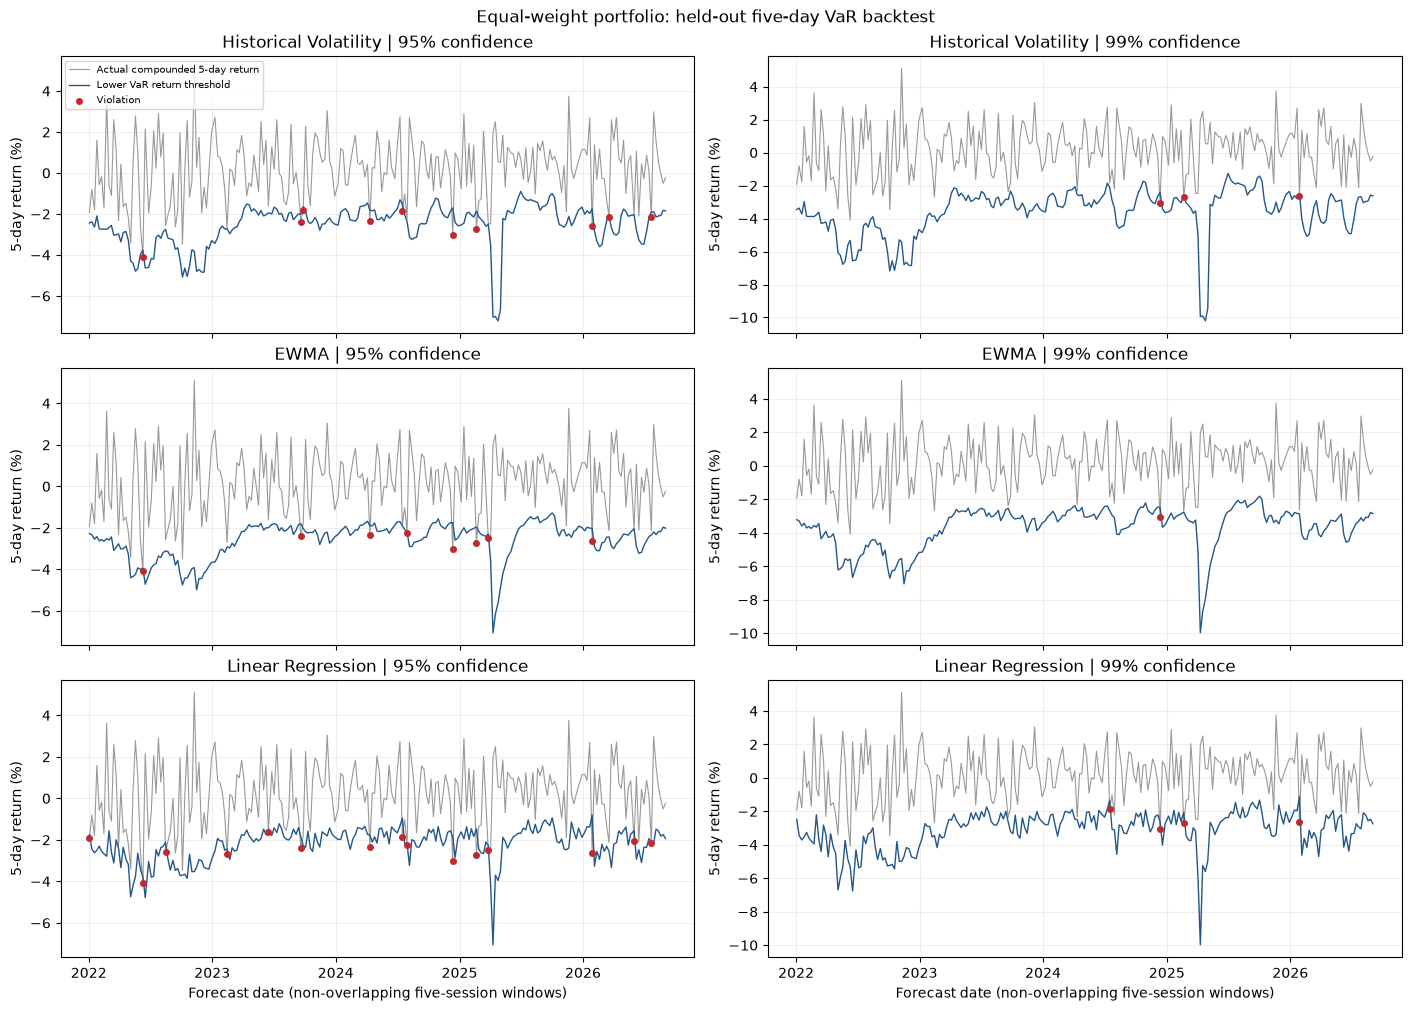

Part 4 completed: VaR forecasts and non-overlapping Kupiec backtests saved.


In [4]:
nonoverlap_dates = predictions.index[::5]
nonoverlap_starts = predictions.loc[nonoverlap_dates, 'target_start']
nonoverlap_ends = predictions.loc[nonoverlap_dates, 'target_end']
assert np.all(
    nonoverlap_starts.iloc[1:].to_numpy()
    > nonoverlap_ends.iloc[:-1].to_numpy()
)

nonoverlap = risk.loc[risk['Date'].isin(nonoverlap_dates)].copy()
nonoverlap.to_csv(TABLE_DIR / 'nonoverlapping_risk_forecasts.csv', index=False)

backtest_rows = []
for (model, confidence), group in nonoverlap.groupby(
    ['model', 'confidence'], sort=False
):
    violations = group['violation'].to_numpy()
    observations = len(group)
    count = int(violations.sum())
    expected_rate = EXPECTED_RATES[confidence]
    statistic, p_value = kupiec_test(violations, expected_rate)
    backtest_rows.append({
        'model': model,
        'confidence': confidence,
        'observations': observations,
        'violations': count,
        'violation_rate': count / observations,
        'expected_violation_rate': expected_rate,
        'kupiec_statistic': statistic,
        'kupiec_p_value': p_value,
    })

backtests = pd.DataFrame(backtest_rows)
backtests.to_csv(TABLE_DIR / 'kupiec_backtests.csv', index=False)

overlapping_summary = (
    risk.groupby(['model', 'confidence'], sort=False)['violation']
    .agg(observations='size', violations='sum', violation_rate='mean')
    .reset_index()
)
overlapping_summary['expected_violation_rate'] = overlapping_summary['confidence'].map(
    EXPECTED_RATES
)
overlapping_summary.to_csv(
    TABLE_DIR / 'overlapping_violation_summary.csv', index=False
)

# The likelihood calculation must remain finite when x=0 or x=n.
for flags in [np.zeros(100, dtype=bool), np.ones(100, dtype=bool)]:
    statistic, p_value = kupiec_test(flags, 0.05)
    assert np.isfinite(statistic) and 0 <= p_value <= 1

display(backtests)
print('Overlapping daily counts (descriptive only):')
display(overlapping_summary)

quality = {
    'status': 'PASS',
    'models': MODELS,
    'confidence_levels': list(Z_SCORES),
    'z_scores': {str(key): value for key, value in Z_SCORES.items()},
    'expected_violation_rates': {
        str(key): value for key, value in EXPECTED_RATES.items()
    },
    'overlapping_observations_per_model_confidence': len(predictions),
    'overlapping_risk_rows': len(risk),
    'nonoverlapping_observations_per_model_confidence': len(nonoverlap_dates),
    'nonoverlapping_risk_rows': len(nonoverlap),
    'nonoverlap_selection': 'every fifth forecast from the first test forecast',
    'main_test_anchor': str(nonoverlap_dates[0].date()),
    'outcome_windows_disjoint': True,
    'all_target_dates_validated': True,
    'fixed_return_checks': [str(date.date()) for date in alignment_check_dates],
    'mean_assumption': 0,
    'horizon_trading_days': 5,
    'annualization_days': 252,
    'part1_daily_returns_sha256': part1_report['processed_sha256']['daily_returns.csv'],
    'part3_test_predictions_sha256': part3_report['test_predictions_sha256'],
}
(TABLE_DIR / 'part4_quality_report.json').write_text(json.dumps(quality, indent=2))

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, constrained_layout=True)
for row, model in enumerate(MODELS):
    for column, confidence in enumerate(Z_SCORES):
        group = nonoverlap.loc[
            (nonoverlap.model == model) & (nonoverlap.confidence == confidence)
        ]
        axis = axes[row, column]
        axis.plot(
            group.Date, group.actual_return_5d * 100,
            color='0.6', linewidth=0.8,
            label='Actual compounded 5-day return',
        )
        axis.plot(
            group.Date, group.return_threshold * 100,
            color='#235789', linewidth=1,
            label='Lower VaR return threshold',
        )
        violations = group.loc[group.violation]
        axis.scatter(
            violations.Date, violations.actual_return_5d * 100,
            color='#c1292e', s=16, zorder=3, label='Violation',
        )
        axis.set_title(f'{model} | {confidence:.0%} confidence')
        axis.set_ylabel('5-day return (%)')
        axis.grid(alpha=0.2)
        if row == 0 and column == 0:
            axis.legend(fontsize=7, loc='upper left')
for axis in axes[-1]:
    axis.set_xlabel('Forecast date (non-overlapping five-session windows)')
fig.suptitle('Equal-weight portfolio: held-out five-day VaR backtest')
fig.savefig(FIGURE_DIR / 'var_violations.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(fig)

print('Part 4 completed: VaR forecasts and non-overlapping Kupiec backtests saved.')